# Hands-On Pertemuan 9: Spark SQL

## Tujuan:
- Mengasah keterampilan analisis data menggunakan Spark SQL.
- Melakukan lebih banyak latihan SQL yang mengarah ke skenario dunia nyata.
- Mempersiapkan mahasiswa untuk menggunakan Spark SQL dalam proyek besar.


### 1. Refresher: Basic SQL Operations in Spark SQL
- **Tugas 1**: Ulangi pemahaman Anda tentang SQL dasar dengan menjalankan queries sederhana pada dataset di Spark SQL.


In [52]:
from pyspark.sql import SparkSession

# Create Spark session
spark = SparkSession.builder.appName('Pertemuan9').getOrCreate()

data = [
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1),
    ('John', 45, 'M', 5000, 2),
    ('Doe', 29, 'F', 3200, 1),
    ('Jane', 31, 'F', 4500, 3)
]
columns = ['Name', 'Age', 'Gender', 'Salary', 'DeptId']
df = spark.createDataFrame(data, schema=columns)
df.createOrReplaceTempView('employees')
spark.sql('SELECT * FROM employees').show()
spark.sql('SELECT Name, Age FROM employees WHERE Salary > 3000').show()
spark.sql('SELECT AVG(Salary) FROM employees').show()


+-----+---+------+------+------+
| Name|Age|Gender|Salary|DeptId|
+-----+---+------+------+------+
|James| 34|     M|  3000|     1|
| Anna| 28|     F|  4100|     2|
|  Lee| 23|     M|  2700|     1|
| John| 45|     M|  5000|     2|
|  Doe| 29|     F|  3200|     1|
| Jane| 31|     F|  4500|     3|
+-----+---+------+------+------+

+----+---+
|Name|Age|
+----+---+
|Anna| 28|
|John| 45|
| Doe| 29|
|Jane| 31|
+----+---+

+-----------+
|avg(Salary)|
+-----------+
|     3750.0|
+-----------+



### 2. Advanced Queries for Data Analysis
Gunakan queries lebih kompleks, melibatkan grouping, filtering, dan subqueries.
- **Tugas 2**: Buat SQL query yang menghitung total gaji berdasarkan jenis kelamin dan usia.


In [53]:
spark.sql('''
SELECT Gender, SUM(Salary) as TotalSalary, Age
FROM employees
GROUP BY Gender, Age
ORDER BY Age
''').show()


+------+-----------+---+
|Gender|TotalSalary|Age|
+------+-----------+---+
|     M|       2700| 23|
|     F|       4100| 28|
|     F|       3200| 29|
|     F|       4500| 31|
|     M|       3000| 34|
|     M|       5000| 45|
+------+-----------+---+



- **Tugas Tambahan 2**: 
1. Cari rata-rata gaji per departemen.
2. Temukan karyawan yang memiliki gaji di atas rata-rata untuk gender masing-masing.
3. Buat ranking karyawan berdasarkan gaji dalam departemen mereka.


In [54]:
# 1. Cari rata-rata gaji per departemen
spark.sql('''
SELECT DeptId, AVG(Salary) as AverageSalary
FROM employees
GROUP BY DeptId
''').show()

# 2. Temukan karyawan yang memiliki gaji di atas rata-rata untuk gender masing-masing
spark.sql('''
WITH AvgSalaryByGender AS (
    SELECT Gender, AVG(Salary) as AvgSalary
    FROM employees
    GROUP BY Gender
)
SELECT e.Name, e.Gender, e.Salary
FROM employees e
JOIN AvgSalaryByGender a
ON e.Gender = a.Gender AND e.Salary > a.AvgSalary
''').show()

# 3. Buat ranking karyawan berdasarkan gaji dalam departemen mereka
spark.sql('''
SELECT Name, DeptId, Salary, 
       DENSE_RANK() OVER (PARTITION BY DeptId ORDER BY Salary DESC) as Rank
FROM employees
''').show()

+------+------------------+
|DeptId|     AverageSalary|
+------+------------------+
|     1|2966.6666666666665|
|     2|            4550.0|
|     3|            4500.0|
+------+------------------+



+----+------+------+
|Name|Gender|Salary|
+----+------+------+
|Anna|     F|  4100|
|John|     M|  5000|
|Jane|     F|  4500|
+----+------+------+

+-----+------+------+----+
| Name|DeptId|Salary|Rank|
+-----+------+------+----+
|  Doe|     1|  3200|   1|
|James|     1|  3000|   2|
|  Lee|     1|  2700|   3|
| John|     2|  5000|   1|
| Anna|     2|  4100|   2|
| Jane|     3|  4500|   1|
+-----+------+------+----+



### 3. Penggunaan Window Functions dan Subqueries
Latihan penggunaan window functions untuk menemukan karyawan dengan gaji tertinggi dan urutannya berdasarkan kelompok usia.
- **Tugas 3**: Terapkan window functions untuk menemukan top 3 karyawan dalam kelompok usia tertentu.


In [55]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

window_spec = Window.partitionBy('Age').orderBy(df['Salary'].desc())

top_employees = df.withColumn('Row_number', row_number().over(window_spec)) \
                  .filter('row_number <= 3') \
                  .select('Name', 'Age', 'Gender', 'Salary', 'Row_Number')

top_employees.show()


+-----+---+------+------+----------+
| Name|Age|Gender|Salary|Row_Number|
+-----+---+------+------+----------+
|  Lee| 23|     M|  2700|         1|
| Anna| 28|     F|  4100|         1|
|  Doe| 29|     F|  3200|         1|
| Jane| 31|     F|  4500|         1|
|James| 34|     M|  3000|         1|
| John| 45|     M|  5000|         1|
+-----+---+------+------+----------+



### 4. Advanced Spark SQL Queries
Menjelajahi queries yang lebih kompleks yang melibatkan multiple joins, subqueries, dan window functions.
- **Tugas 4**: Demonstrasi penggunaan multi-level joins dan subqueries untuk analisis data yang mendalam.


In [56]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Pertemuan9').getOrCreate()

# Data setup for complex SQL queries
employees = spark.createDataFrame([
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
], ['Name', 'Age', 'Gender', 'Salary', 'DeptId'])
departments = spark.createDataFrame([
    (1, 'HR'),
    (2, 'Marketing')
], ['DeptId', 'DeptName'])
projects = spark.createDataFrame([
    (1, 'Project A'),
    (2, 'Project B')
], ['DeptId', 'ProjectName'])
employees.createOrReplaceTempView('employees')
departments.createOrReplaceTempView('departments')
projects.createOrReplaceTempView('projects')

# Complex SQL query involving multiple joins and subqueries
spark.sql('''
SELECT e.Name, e.Age, d.DeptName, p.ProjectName
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
JOIN projects p ON e.DeptId = p.DeptId
''').show()


+-----+---+---------+-----------+
| Name|Age| DeptName|ProjectName|
+-----+---+---------+-----------+
|  Lee| 23|       HR|  Project A|
|James| 34|       HR|  Project A|
| Anna| 28|Marketing|  Project B|
+-----+---+---------+-----------+



Latihan mandiri untuk memperkuat pemahaman tentang Spark SQL dalam analisis data terdistribusi.
- **Tugas 5**: Tuliskan query SQL untuk menemukan rata-rata gaji per departemen dan rangking setiap karyawan dalam departemen berdasarkan gaji.
- **Tugas 6**: Gunakan window functions untuk menentukan tren gaji berdasarkan usia di setiap departemen.


In [57]:
from pyspark.sql.functions import avg

# Tugas 5
spark.sql('''
SELECT DeptId, Name, Salary, 
    AVG(Salary) OVER (PARTITION BY DeptId) as AvgSalary,
    DENSE_RANK() OVER (PARTITION BY DeptId ORDER BY Salary DESC) as Rank
FROM employees
''').show()

# Tugas 6

window_spec_dept_age = Window.partitionBy('DeptId', 'Age').orderBy('Age')

salary_trends_dept_age = df.withColumn('AvgSalary', avg('Salary').over(window_spec_dept_age)) \
                  .select('DeptId', 'Age', 'AvgSalary') \
                  .distinct() \
                  .orderBy('DeptId', 'Age').show()

+------+-----+------+---------+----+
|DeptId| Name|Salary|AvgSalary|Rank|
+------+-----+------+---------+----+
|     1|James|  3000|   2850.0|   1|
|     1|  Lee|  2700|   2850.0|   2|
|     2| Anna|  4100|   4100.0|   1|
+------+-----+------+---------+----+

+------+---+---------+
|DeptId|Age|AvgSalary|
+------+---+---------+
|     1| 23|   2700.0|
|     1| 29|   3200.0|
|     1| 34|   3000.0|
|     2| 28|   4100.0|
|     2| 45|   5000.0|
|     3| 31|   4500.0|
+------+---+---------+



### 5. Advanced Data Analysis and Visualization
Penerapan teknik analisis data yang lebih canggih dan visualisasi menggunakan PySpark dan matplotlib.
- **Tugas 7**: Lakukan analisis tren gaji menggunakan Spark SQL dan visualisasikan hasilnya.


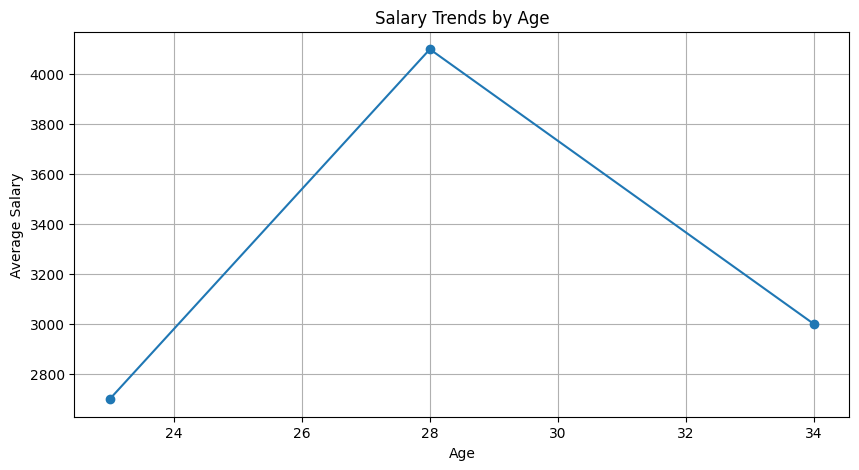

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Advanced data analysis with visualization
salary_trends = spark.sql('''
SELECT Age, AVG(Salary) AS AverageSalary
FROM employees
GROUP BY Age
ORDER BY Age
''').toPandas()

# Visualization of salary trends
plt.figure(figsize=(10, 5))
plt.plot(salary_trends['Age'], salary_trends['AverageSalary'], marker='o')
plt.xlabel('Age')
plt.ylabel('Average Salary')
plt.title('Salary Trends by Age')
plt.grid(True)
plt.show()


### 6. Homework
- **Tugas 1**: Gunakan Spark SQL untuk mencari total gaji dan jumlah karyawan per departemen. Buat visualisasi perbandingan antar departemen.
- **Tugas 2**: Temukan karyawan dengan gaji di atas rata-rata dalam setiap kelompok usia dan visualisasikan data ini dalam bentuk grafik batang atau pie chart.
- **Tugas 3**: Buat dataset yang lebih besar (misalnya, 100+ baris) dan lakukan analisis mendalam menggunakan SQL functions seperti `SUM()`, `AVG()`, `COUNT()`, serta `JOIN` antar tabel serta buat visualisasi yang menarik.


+------+-----------+-------------+
|DeptId|TotalSalary|EmployeeCount|
+------+-----------+-------------+
|     1|       5700|            2|
|     2|       4100|            1|
+------+-----------+-------------+



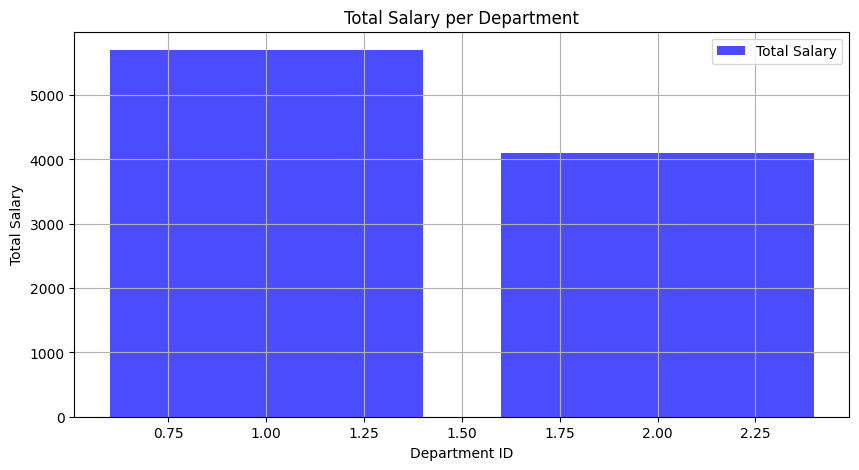

In [59]:
import random

# Tugas 1: Total gaji dan jumlah karyawan per departemen
total_salary_and_count = spark.sql('''
SELECT DeptId, SUM(Salary) as TotalSalary, COUNT(Name) as EmployeeCount
FROM employees
GROUP BY DeptId
''')
total_salary_and_count.show()

# Convert to Pandas for visualization
total_salary_and_count_pd = total_salary_and_count.toPandas()

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(total_salary_and_count_pd['DeptId'], total_salary_and_count_pd['TotalSalary'], color='blue', alpha=0.7, label='Total Salary')
plt.xlabel('Department ID')
plt.ylabel('Total Salary')
plt.title('Total Salary per Department')
plt.legend()
plt.grid(True)
plt.show()



+----+---+------+
|Name|Age|Salary|
+----+---+------+
+----+---+------+



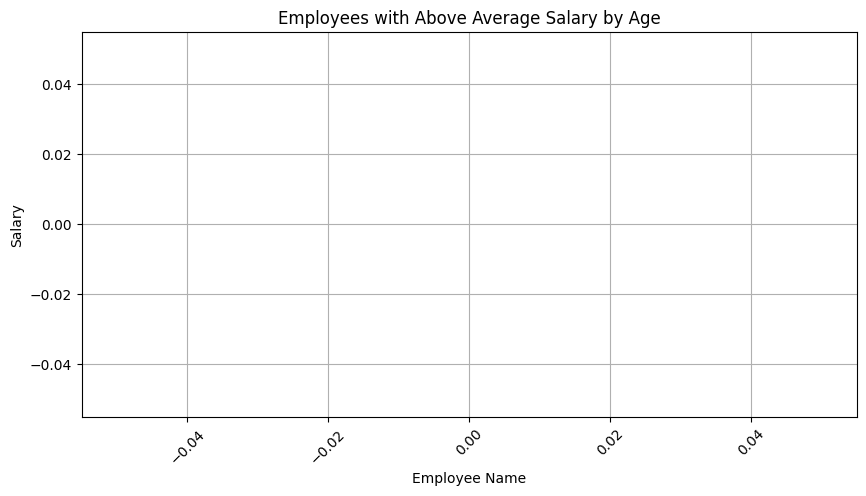

In [60]:
# Tugas 2: Karyawan dengan gaji di atas rata-rata dalam setiap kelompok usia
above_avg_salary_by_age = spark.sql('''
WITH AvgSalaryByAge AS (
    SELECT Age, AVG(Salary) as AvgSalary
    FROM employees
    GROUP BY Age
)
SELECT e.Name, e.Age, e.Salary
FROM employees e
JOIN AvgSalaryByAge a
ON e.Age = a.Age AND e.Salary > a.AvgSalary
''')
above_avg_salary_by_age.show()

# Convert to Pandas for visualization
above_avg_salary_by_age_pd = above_avg_salary_by_age.toPandas()

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(above_avg_salary_by_age_pd['Name'], above_avg_salary_by_age_pd['Salary'], color='green', alpha=0.7)
plt.xlabel('Employee Name')
plt.ylabel('Salary')
plt.title('Employees with Above Average Salary by Age')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



+------+-----------+-----------------+-------------+
|DeptId|TotalSalary|        AvgSalary|EmployeeCount|
+------+-----------+-----------------+-------------+
|     5|      82104|           5473.6|           15|
|     1|     107500|5119.047619047619|           21|
|     3|     134152|4968.592592592592|           27|
|     2|      91726|           4586.3|           20|
|     4|      82142|4831.882352941177|           17|
+------+-----------+-----------------+-------------+



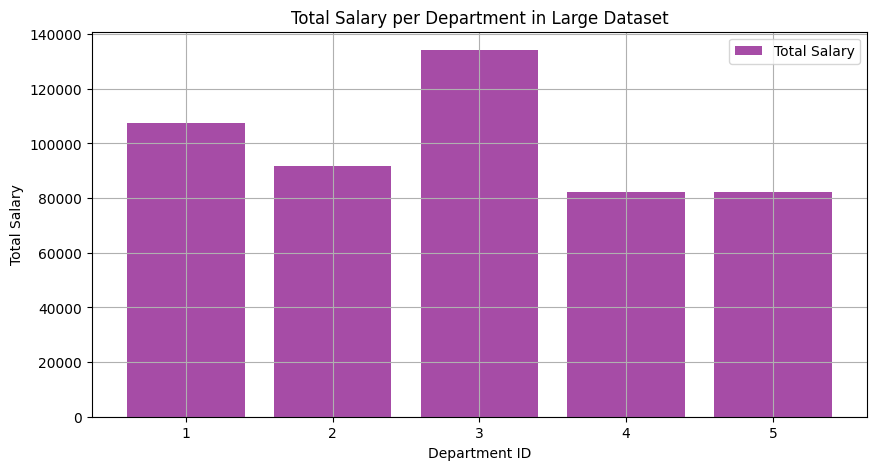

In [61]:
# Tugas 3: Buat dataset yang lebih besar dan lakukan analisis mendalam

# Generate larger dataset
random.seed(42)
large_data = [(f'Employee{i}', random.randint(20, 60), random.choice(['M', 'F']), random.randint(2000, 8000), random.randint(1, 5)) for i in range(1, 101)]
large_df = spark.createDataFrame(large_data, schema=columns)
large_df.createOrReplaceTempView('large_employees')

# Analysis using SQL functions
large_salary_analysis = spark.sql('''
SELECT DeptId, 
       SUM(Salary) as TotalSalary, 
       AVG(Salary) as AvgSalary, 
       COUNT(Name) as EmployeeCount
FROM large_employees
GROUP BY DeptId
''')
large_salary_analysis.show()

# Convert to Pandas for visualization
large_salary_analysis_pd = large_salary_analysis.toPandas()

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(large_salary_analysis_pd['DeptId'], large_salary_analysis_pd['TotalSalary'], color='purple', alpha=0.7, label='Total Salary')
plt.xlabel('Department ID')
plt.ylabel('Total Salary')
plt.title('Total Salary per Department in Large Dataset')
plt.legend()
plt.grid(True)
plt.show()